# Clustering K-Prototypes

How K-Prototypes Works

Dissimilarity = numeric distance + γ × categorical distance

Numeric distance: Euclidean distance on continuous variables (here, sin, cos, plus other numerics).

Categorical distance: simple mismatch count (0 if same category, 1 if different).

γ tells the algorithm how “expensive” it is to belong to different categories.

In [188]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

In [189]:
df = pd.read_parquet(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\012_data_cluster_ready.parquet").copy()
print('Number of accidents: ', df.shape[0],
      '\nNumber of variables:', df.shape[1])

Number of accidents:  14849 
Number of variables: 36


### COLUMNS INVENTORY

What are the existing columns?

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-null  int32                      
 9   DataOraIncidente 

##### RANDOM FOREST - DECIDING WHICH VARIABLES ARE RELATED TO ACCIDENT SEVERITY

In [191]:
numerical_for_clustering = ['Latitude',
                            'Longitude',
                            'time_sin',
                            'time_cos',
                            'temperature_2m (°C)',
                            'relative_humidity_2m (%)',
                            'precipitation (mm)',
                            'wind_gusts_10m (km/h)',
                            'weather_days_since_last_rain',
                            'male_proportion']

categorical_for_clustering = ['multiple_pedestrians',
                              'driver_injury',
                              'driver_gender',
                              'natural_light',
                              'DAY',
                              'road_features',
                              'road_markings_traffic_lights',
                              'TipoStradaDifficulty',
                              'traffic_density',
                              'vehicle_type',
                              'hit_and_run',
                              'passengers',
                              'road_conditions_bin',
                              'road_signage',
                              'weather_group']

target = 'severity_winsorized'  # String (not list)

Fitting Random Forest Classifier...
Model Score: 0.8032

TOP 15 MOST IMPORTANT FEATURES
multiple_pedestrians_1          0.305729
multiple_pedestrians_0          0.296727
male_proportion                 0.045016
Latitude                        0.037713
Longitude                       0.034641
temperature_2m (°C)             0.028401
time_cos                        0.026794
wind_gusts_10m (km/h)           0.026110
relative_humidity_2m (%)        0.025629
time_sin                        0.024705
weather_days_since_last_rain    0.022427
precipitation (mm)              0.006601
driver_injury_0                 0.005387
TipoStradaDifficulty_1          0.005103
driver_injury_1                 0.004940
dtype: float64

BOTTOM 10 LEAST IMPORTANT FEATURES
weather_group_Wet—Rain            0.001216
road_markings_traffic_lights_1    0.001102
driver_gender_U                   0.001055
vehicle_type_Van                  0.000918
hit_and_run_1                     0.000917
hit_and_run_0                  

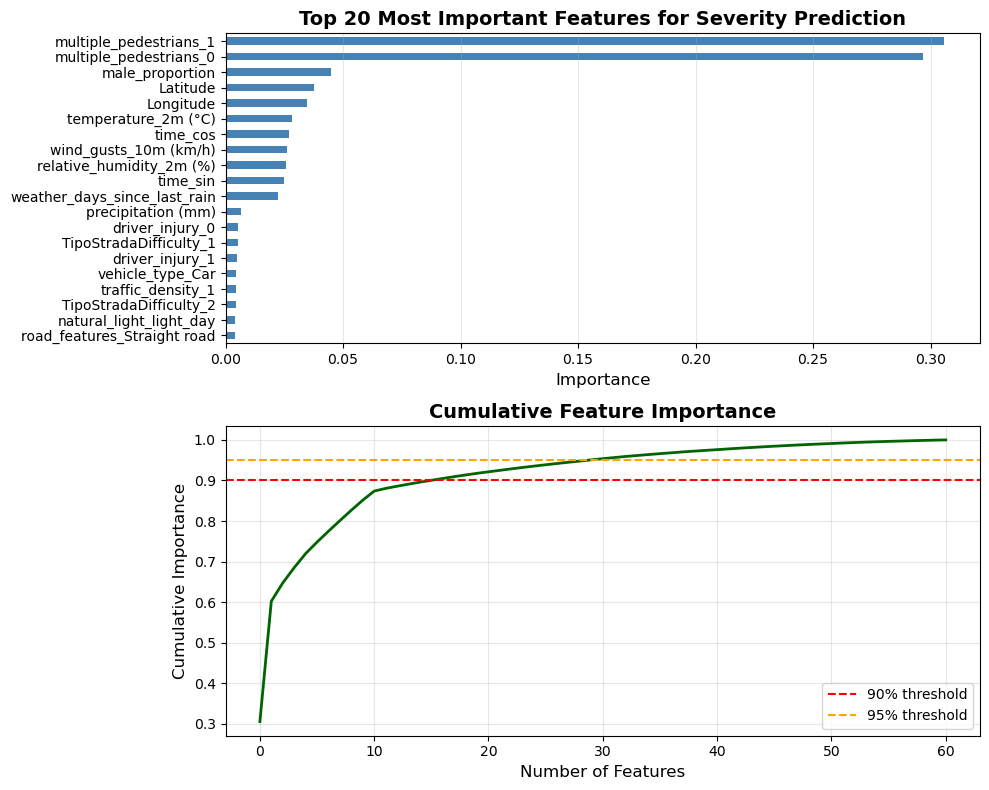


IMPORTANCE BY FEATURE TYPE

Numerical Features:
male_proportion                 0.045016
Latitude                        0.037713
Longitude                       0.034641
temperature_2m (°C)             0.028401
time_cos                        0.026794
wind_gusts_10m (km/h)           0.026110
relative_humidity_2m (%)        0.025629
time_sin                        0.024705
weather_days_since_last_rain    0.022427
precipitation (mm)              0.006601
dtype: float64
Total numerical importance: 0.2780

Categorical Features (aggregated by original feature):
multiple_pedestrians                    : 0.6025
driver_injury                           : 0.0103
driver_gender                           : 0.0079
natural_light                           : 0.0097
DAY                                     : 0.0178
road_features                           : 0.0090
road_markings_traffic_lights            : 0.0023
TipoStradaDifficulty                    : 0.0140
traffic_density                         : 0

In [192]:
# Prepare features and target
X = df[categorical_for_clustering + numerical_for_clustering].copy()
y = df[target].values.ravel()  # Fix for the warning: convert to 1D array

# Preprocessor: StandardScaler for numeric, OneHotEncoder for categorical
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         categorical_for_clustering),
        ("num", StandardScaler(), numerical_for_clustering)  # Added scaling
    ]
)

# Build pipeline
clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        max_depth=10,  # Prevent overfitting
        min_samples_split=20,
        min_samples_leaf=10
    ))
])

# Fit the model
print("Fitting Random Forest Classifier...")
clf.fit(X, y)
print(f"Model Score: {clf.score(X, y):.4f}")

# Extract feature names
ohe = clf.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_for_clustering)
all_features = list(cat_feature_names) + numerical_for_clustering

# Get feature importances
importances = clf.named_steps["classifier"].feature_importances_
feat_imp = pd.Series(
    importances, index=all_features).sort_values(ascending=False)

# Display results
print("\n" + "="*60)
print("TOP 15 MOST IMPORTANT FEATURES")
print("="*60)
print(feat_imp.head(15))

print("\n" + "="*60)
print("BOTTOM 10 LEAST IMPORTANT FEATURES")
print("="*60)
print(feat_imp.tail(10))

# Calculate cumulative importance
cumsum = feat_imp.sort_values(ascending=False).cumsum()
n_features_90 = (cumsum <= 0.90).sum()
print(f"\n{n_features_90} features explain 90% of importance")
print(f"Total features: {len(feat_imp)}")

# Visualization
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Top 20 features
feat_imp.head(20).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Importance', fontsize=12)
axes[0].set_title('Top 20 Most Important Features for Severity Prediction',
                  fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Cumulative importance
cumsum_sorted = feat_imp.sort_values(ascending=False).cumsum()
axes[1].plot(range(len(cumsum_sorted)), cumsum_sorted,
             linewidth=2, color='darkgreen')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Features', fontsize=12)
axes[1].set_ylabel('Cumulative Importance', fontsize=12)
axes[1].set_title('Cumulative Feature Importance',
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Group importances by feature type
print("\n" + "="*60)
print("IMPORTANCE BY FEATURE TYPE")
print("="*60)

# Numerical features
num_importance = feat_imp[numerical_for_clustering].sort_values(
    ascending=False)
print("\nNumerical Features:")
print(num_importance)
print(f"Total numerical importance: {num_importance.sum():.4f}")

# Categorical features (sum by original category)
print("\nCategorical Features (aggregated by original feature):")
for cat_feature in categorical_for_clustering:
    cat_cols = [col for col in cat_feature_names if col.startswith(
        cat_feature + "_")]
    if cat_cols:
        total_imp = feat_imp[cat_cols].sum()
        print(f"{cat_feature:40s}: {total_imp:.4f}")

# Recommended features for clustering (90% threshold)
recommended_features = feat_imp.nlargest(n_features_90).index.tolist()
print("\n" + "="*60)
print(f"RECOMMENDED FEATURES FOR CLUSTERING (top {n_features_90})")
print("="*60)
for i, feat in enumerate(recommended_features, 1):
    print(f"{i:2d}. {feat:50s} ({feat_imp[feat]:.4f})")

The Random Forest Classifier seems to indicate the features which should be retained:
- proportion of male pedestrians 
- position (Lat, Long) 
- multiple pedestrians, although this may just be because accidents with multiple pedestrians are inherently more severe
- time of day (tod or temperature/humidity)
- wind gusts
- days since last rain

The Random Forest Classifier seems to indicate the features which could be removed/altered:
- hit and run
- weather 
- road signage
- consolidate vehicle groups?

However, the random forest classifier indicates which features predict severity, rather than finding groups of patterns in the accident dataset. Even if a feature has a low predicitve power for injury severity, it may still be useful for clustering. 

We will compare this with PCA analysis:

# PCA to Identify Redundant NUMERICAL Features

In [193]:
numerical_for_PCA = ['severity_winsorized'] + numerical_for_clustering

Features included in PCA analysis (11):
['severity_winsorized', 'Latitude', 'Longitude', 'time_sin', 'time_cos', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'precipitation (mm)', 'wind_gusts_10m (km/h)', 'weather_days_since_last_rain', 'male_proportion']

PCA VARIANCE ANALYSIS
Total features: 11
Components for 90% variance: 9
Components for 95% variance: 10

If you had NO redundancy, you'd need ~11 components
Actual needed: 9 components → compression ratio: 81.8%


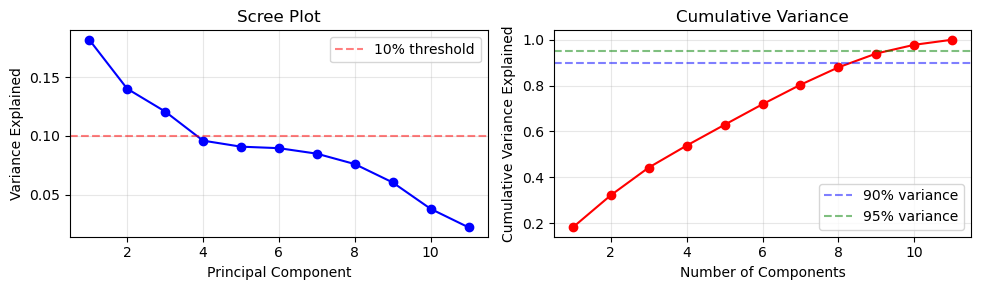


LOADINGS FOR FIRST 5 COMPONENTS
                                PC1    PC2    PC3    PC4    PC5
severity_winsorized          -0.082  0.037 -0.100  0.634  0.368
Latitude                     -0.030 -0.004  0.013 -0.549  0.106
Longitude                     0.012  0.022 -0.055  0.527 -0.422
time_sin                     -0.082 -0.631  0.345  0.083 -0.126
time_cos                     -0.331  0.418 -0.496 -0.035  0.092
temperature_2m (°C)           0.550  0.100 -0.131  0.030  0.006
relative_humidity_2m (%)     -0.647 -0.042  0.071 -0.013  0.002
precipitation (mm)           -0.182  0.375  0.445  0.031 -0.046
wind_gusts_10m (km/h)         0.293  0.440  0.414  0.024 -0.045
weather_days_since_last_rain  0.180 -0.266 -0.434 -0.042  0.052
male_proportion              -0.064  0.089 -0.204 -0.082 -0.803

DOMINANT FEATURES PER COMPONENT (|loading| > 0.3)

PC1 (explains 18.2% of variance):
  relative_humidity_2m (%)                : -0.647
  temperature_2m (°C)                     :  0.550
  time_cos 

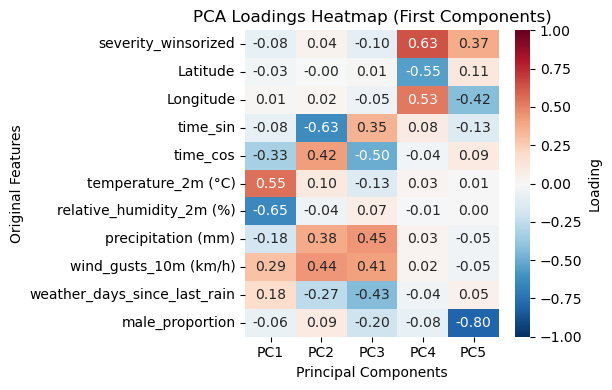


REDUNDANCY CHECK
Features that load heavily together on the same PC are likely redundant:

PC1: Features loading together (|loading| > 0.4):
  relative_humidity_2m (%)                : -0.647
  temperature_2m (°C)                     :  0.550

PC2: Features loading together (|loading| > 0.4):
  time_sin                                : -0.631
  wind_gusts_10m (km/h)                   :  0.440
  time_cos                                :  0.418

PC3: Features loading together (|loading| > 0.4):
  time_cos                                : -0.496
  precipitation (mm)                      :  0.445
  weather_days_since_last_rain            : -0.434
  wind_gusts_10m (km/h)                   :  0.414


In [194]:
from sklearn.decomposition import PCA

print(f"Features included in PCA analysis ({len(numerical_for_PCA)}):")
print(numerical_for_PCA)

# Create the dataset
num_pruned = df[numerical_for_PCA].copy()

# Standardize (PCA requires scaled data)
scaler = StandardScaler()
num_pruned_scaled = scaler.fit_transform(num_pruned)
num_pruned_scaled = pd.DataFrame(num_pruned_scaled, columns=numerical_for_PCA)

# Fit PCA
pca = PCA()
pca.fit(num_pruned_scaled)

# How many components explain 90% of variance?
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
explained90 = np.argmax(cumsum_var >= 0.90) + 1
explained95 = np.argmax(cumsum_var >= 0.95) + 1

print("\n" + "="*60)
print("PCA VARIANCE ANALYSIS")
print("="*60)
print(f"Total features: {len(numerical_for_PCA)}")
print(f"Components for 90% variance: {explained90}")
print(f"Components for 95% variance: {explained95}")
print(
    f"\nIf you had NO redundancy, you'd need ~{len(numerical_for_PCA)} components")
print(
    f"Actual needed: {explained90} components → compression ratio: {explained90/len(numerical_for_PCA):.1%}")

# Scree plot
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_, 'bo-')
plt.axhline(y=0.1, color='r', linestyle='--', alpha=0.5, label='10% threshold')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.title('Scree Plot')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum_var) + 1), cumsum_var, 'ro-')
plt.axhline(y=0.90, color='b', linestyle='--', alpha=0.5, label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', alpha=0.5, label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('Cumulative Variance')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Inspect loadings for first few components
n_components_to_show = min(5, explained95)
loadings = pd.DataFrame(
    pca.components_[:n_components_to_show].T,
    columns=[f'PC{i+1}' for i in range(n_components_to_show)],
    index=numerical_for_PCA
)

print("\n" + "="*60)
print(f"LOADINGS FOR FIRST {n_components_to_show} COMPONENTS")
print("="*60)
print(loadings.round(3))

# Identify dominant features in each PC
print("\n" + "="*60)
print("DOMINANT FEATURES PER COMPONENT (|loading| > 0.3)")
print("="*60)
for col in loadings.columns:
    dominant = loadings[abs(loadings[col]) > 0.3][col].sort_values(
        key=abs, ascending=False)
    print(
        f"\n{col} (explains {pca.explained_variance_ratio_[int(col[2:])-1]:.1%} of variance):")
    for feat, loading in dominant.items():
        print(f"  {feat:40s}: {loading:6.3f}")

# Heatmap of loadings
plt.figure(figsize=(6, 4))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, cbar_kws={'label': 'Loading'})
plt.title('PCA Loadings Heatmap (First Components)')
plt.xlabel('Principal Components')
plt.ylabel('Original Features')
plt.tight_layout()
plt.show()

# Check for potential redundancy
print("\n" + "="*60)
print("REDUNDANCY CHECK")
print("="*60)
print("Features that load heavily together on the same PC are likely redundant:")

for i in range(min(3, n_components_to_show)):
    pc_name = f'PC{i+1}'
    high_loadings = loadings[abs(loadings[pc_name]) > 0.4][pc_name]
    if len(high_loadings) > 1:
        print(f"\n{pc_name}: Features loading together (|loading| > 0.4):")
        for feat, loading in high_loadings.sort_values(key=abs, ascending=False).items():
            print(f"  {feat:40s}: {loading:6.3f}")

#### NUMERICAL FEATURES REDUNDANCY CHECK CONCLUSIONS
There is minimal redundancy in this choice of numerical components. 9 out of 11 features explain 90% of the variance (82% compression ratio). 

##### Component Interpretation:
PC1 (18.2% variance) - "Weather/Temperature Factor"
- Humidity (-0.647) vs Temperature (+0.550): Negatively correlated (as expected - hot days are less humid)
Verdict: These two features capture related but distinct information. The opposite signs show they're complementary, not redundant.

PC2 (14.0% variance) - "Time-of-Day & Wind/Rain Factor"
- Time indicators (time_sin, time_cos) dominate
- Wind gusts & precipitation also load here
Verdict: Confirms weather varies by time of day (as we saw in Kruskal-Wallis), but they're not perfectly redundant

PC3 (12.1% variance) - "Rain History & Current Weather"
- Precipitation (+0.445) vs Days since rain (-0.434): Opposite relationship 
- Wind gusts and time also present
Verdict: Shows some overlap between rain measures, but not severe

PC4 (9.6% variance) - "Severity & Location Factor"
- Severity and Lat/Long loading together
Verdict: Geographic patterns in accident severity

PC5 (9.1% variance) - "Gender Composition Factor"
- Male proportion dominates (-0.803)
Verdict: Gender is an independent dimension

Redundancy Check Summary:
- Temperature vs Humidity (PC1): Opposite signs = complementary, not redundant
- Time variables (PC2, PC3): Expected to capture temporal patterns - keep both sin/cos for circular time
- Rain measures (PC3): Moderate correlation but capture different aspects (current vs history)

Weather and time variables do overlap somewhat (PC2, PC3), but this reflects real-world patterns (weather changes by time of day) rather than pure redundancy

No single component has 3 or more features loading > 0.6 (no severe multicollinearity)

Each feature adds unique information on severity, location, time, weather and gender

# Cramér's V to Identify Redundant CATEGORICAL Features
Check correlation between categorical variables:

CRAMÉR'S V - CATEGORICAL ASSOCIATIONS


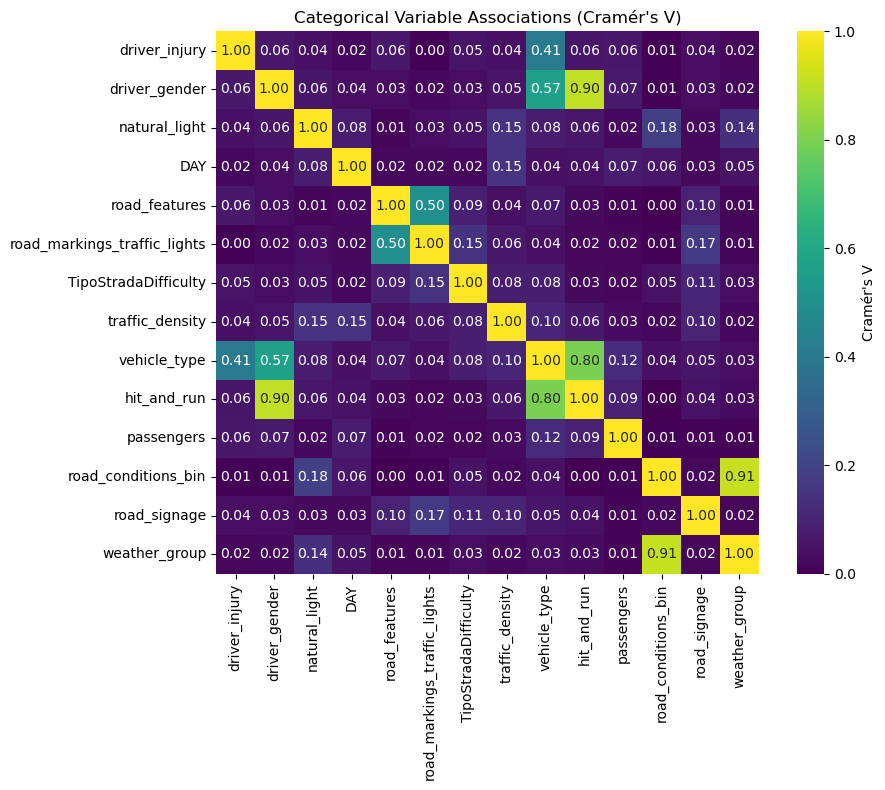


High associations (Cramér's V > 0.5):
  driver_gender <-> vehicle_type: 0.566
  driver_gender <-> hit_and_run: 0.904
  vehicle_type <-> hit_and_run: 0.798
  road_conditions_bin <-> weather_group: 0.913


In [195]:
from scipy.stats import chi2_contingency


def cramers_v(x, y):
    """Calculate Cramér's V statistic for categorical association"""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))


# Calculate Cramér's V for all categorical pairs
categorical_vars = categorical_for_clustering.copy()
if 'severity_winsorized' in categorical_vars:
    categorical_vars.remove('severity_winsorized')
if 'multiple_pedestrians' in categorical_vars:
    categorical_vars.remove('multiple_pedestrians')

n_cat = len(categorical_vars)
cramers_matrix = np.zeros((n_cat, n_cat))

print("="*60)
print("CRAMÉR'S V - CATEGORICAL ASSOCIATIONS")
print("="*60)

for i, var1 in enumerate(categorical_vars):
    for j, var2 in enumerate(categorical_vars):
        if i <= j:
            if i == j:
                cramers_matrix[i, j] = 1.0
            else:
                cv = cramers_v(df[var1], df[var2])
                cramers_matrix[i, j] = cv
                cramers_matrix[j, i] = cv

cramers_df = pd.DataFrame(cramers_matrix,
                          index=categorical_vars,
                          columns=categorical_vars)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cramers_df, annot=True, fmt='.2f', cmap='viridis',
            vmin=0, vmax=1, square=True, cbar_kws={'label': "Cramér's V"})
plt.title("Categorical Variable Associations (Cramér's V)")
plt.tight_layout()
plt.show()

# Find high associations (potential redundancy)
print("\nHigh associations (Cramér's V > 0.5):")
for i, var1 in enumerate(categorical_vars):
    for j, var2 in enumerate(categorical_vars):
        if i < j and cramers_matrix[i, j] > 0.5:
            print(f"  {var1} <-> {var2}: {cramers_matrix[i, j]:.3f}")

#### CRITICAL ISSUES CATEGORICAL FEATURES

HIT & RUN ACCIDENTS 
- driver_gender ↔ hit_and_run: 0.904 (high)
- vehicle_type ↔ hit_and_run: 0.798 (high)
- driver_gender ↔ vehicle_type: 0.566 (moderate/high)

In hit-and-run cases, driver info is often unknown/missing, most likely creating high correlations between driver_gender_unknown and vehicle_type_unknown. In order to retain information on vehicle types, we will eliminate the binary signal hit_and_run.

In [196]:
df = df.drop(columns=['hit_and_run'])
categorical_for_clustering.remove('hit_and_run')

WEATHER VARIABLES
- road_conditions_bin ↔ weather_group: 0.913 (very high)

The road conditions (dry = 0, wet/slippery = 1) are very highly correlated with the weather_group. We will keep the road conditions, as they have a direct effect on accident risk and weather issues are already included in other features (temperature, humidity, precipitation, wind gusts). 

The weather_group was influenced by the information from the weather forecast, so we will drop this feature and keep road_conditions_bin.

In [197]:
df = df.drop(columns=['weather_group'])
categorical_for_clustering.remove('weather_group')

FINAL CATEGORICAL CHECK:

In [198]:
# Re-run Cramér's V on cleaned categorical list to confirm
import numpy as np
from scipy.stats import chi2_contingency
print("\n" + "="*60)
print("VERIFICATION: Remaining High Associations (V > 0.5)?")
print("="*60)


def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))


high_v_found = False
for i, var1 in enumerate(categorical_for_clustering):
    for j in range(i+1, len(categorical_for_clustering)):
        var2 = categorical_for_clustering[j]
        v = cramers_v(df[var1], df[var2])
        if v > 0.5:
            print(f"  {var1} <-> {var2}: {v:.3f}")
            high_v_found = True

if not high_v_found:
    print("  ✓ No associations above 0.5 - good to go!")


VERIFICATION: Remaining High Associations (V > 0.5)?
  driver_gender <-> vehicle_type: 0.566


In [199]:
from scipy.stats import kruskal
print("="*60)
print("DRIVER GENDER ANALYSIS")
print("="*60)

print("\nDriver gender distribution:")
print(df['driver_gender'].value_counts())
print(f"\nPercentages:")
print(df['driver_gender'].value_counts(normalize=True).round(3) * 100)

# Check if "always male" finding holds
male_categories = ['male', 'Male', 'M', 'm']  # adjust based on your data
female_categories = ['female', 'Female', 'F', 'f']
unknown_categories = ['unknown', 'Unknown', 'U', 'u', 'not_known', 'Not Known']

# Count each category
male_count = df[df['driver_gender'].isin(male_categories)].shape[0]
female_count = df[df['driver_gender'].isin(female_categories)].shape[0]
unknown_count = df[df['driver_gender'].isin(unknown_categories)].shape[0]
total_known_gender = male_count + female_count

print(f"\n{'='*60}")
print(f"Driver Gender Breakdown:")
print(f"  Male drivers: {male_count:,} ({male_count/len(df)*100:.1f}% of all)")
print(
    f"  Female drivers: {female_count:,} ({female_count/len(df)*100:.1f}% of all)")
print(
    f"  Unknown: {unknown_count:,} ({unknown_count/len(df)*100:.1f}% of all)")
print(
    f"\nOf cases with KNOWN driver gender ({total_known_gender:,} accidents):")
if total_known_gender > 0:
    male_pct = male_count / total_known_gender * 100
    female_pct = female_count / total_known_gender * 100
    print(f"  Male: {male_pct:.1f}%")
    print(f"  Female: {female_pct:.1f}%")

# Check by vehicle type
print("\n" + "="*60)
print("Driver Gender by Vehicle Type")
print("="*60)
ct = pd.crosstab(df['driver_gender'], df['vehicle_type'], margins=True)
print(ct)

print("\n(Column percentages):")
ct_pct = pd.crosstab(df['driver_gender'],
                     df['vehicle_type'], normalize='columns') * 100
print(ct_pct.round(1))

# Check relationship with severity
print("\n" + "="*60)
print("Driver Gender vs Severity (Kruskal-Wallis)")
print("="*60)

groups = [df[df['driver_gender'] == gender]['severity_winsorized'].dropna()
          for gender in df['driver_gender'].unique()]
groups = [g for g in groups if len(g) > 0]

if len(groups) >= 2:
    stat, p_value = kruskal(*groups)
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"Does severity differ by driver gender? p={p_value:.4f} {sig}")

DRIVER GENDER ANALYSIS

Driver gender distribution:
driver_gender
M    10979
F     3130
U      740
Name: count, dtype: int64

Percentages:
driver_gender
M    73.9
F    21.1
U     5.0
Name: proportion, dtype: float64

Driver Gender Breakdown:
  Male drivers: 10,979 (73.9% of all)
  Female drivers: 3,130 (21.1% of all)
  Unknown: 740 (5.0% of all)

Of cases with KNOWN driver gender (14,109 accidents):
  Male: 77.8%
  Female: 22.2%

Driver Gender by Vehicle Type
vehicle_type   Bicycle_or_Moped   Car  Heavy_or_Special  \
driver_gender                                             
M                           277  6948               341   
F                            76  2702                15   
U                            16   193                 4   
All                         369  9843               360   

vehicle_type   Motorcycle_or_scooter  Unknown  Van    All  
driver_gender                                              
M                               2784       11  618  10979  
F

Drive gender only has 5% missing values, 22% female and the rest male. Although V = 0.566 is moderately high, it may just be reflective of actual gender imbalances in society today: most taxi / lorry drivers are male; most motorcyclists are male; in cars, most drivers are male, etc. p is very small, indicating that severity changes significantly by gender. 

We will keep the feature driver_gender.

In [200]:
df.to_parquet('013_data_for_clustering.parquet', index=False)

In [201]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-null  int32                      
 9   DataOraIncidente 

# FINAL COLUMN CHECK

In [202]:
numerical_for_clustering = [  # 'Latitude',
    # 'Longitude',
    'time_sin',
    'time_cos',
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'precipitation (mm)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain',
    'male_proportion']

categorical_for_clustering = ['multiple_pedestrians',
                              'driver_injury',
                              'driver_gender',
                              'natural_light',
                              'DAY',
                              'road_features',
                              'road_markings_traffic_lights',
                              'TipoStradaDifficulty',
                              'traffic_density',
                              'vehicle_type',
                              # 'hit_and_run',
                              'passengers',
                              'road_conditions_bin',
                              'road_signage',
                              # 'weather_group',
                              'severity_winsorized']

In [203]:
columns_for_analysis = categorical_for_clustering + numerical_for_clustering
df_filtered = df[columns_for_analysis].copy()

Now we double-check we have every column included and no duplicates:

In [204]:
import difflib
from collections import Counter

df_cols = df_filtered.columns.tolist()
cat = list(categorical_for_clustering)
num = list(numerical_for_clustering)

# De-dupe while preserving order for the combined "used" list
used_cols = []
for c in cat + num:
    if c not in used_cols:
        used_cols.append(c)

# 1) In df but not in your lists
unaccounted_in_df = [c for c in df_cols if c not in used_cols]

# 2) In your lists but not in df  (these are your "extra columns" in the lists)
extra_in_lists = [c for c in used_cols if c not in df_cols]

# 3) Duplicates inside each list
dups_cat = [c for c, cnt in Counter(cat).items() if cnt > 1]
dups_num = [c for c, cnt in Counter(num).items() if cnt > 1]

# 4) Same column listed as both categorical and numerical
overlap = [c for c in cat if c in num]  # preserves order from categorical list

print("=== Coverage report ===")
print(f"Total df cols: {len(df_cols)}  | Used: {len(used_cols)}")
print(f"Unaccounted in df ({len(unaccounted_in_df)}): {unaccounted_in_df}")
print(
    f"Extra in your lists, not in df ({len(extra_in_lists)}): {extra_in_lists}")
print(f"Duplicates in categorical_cols: {dups_cat}")
print(f"Duplicates in numerical_cols:   {dups_num}")
print(f"Overlap between cat & num:      {overlap}")

# Dtypes for unaccounted columns (guard if empty)
if unaccounted_in_df:
    print("\nDtypes of unaccounted df columns:\n",
          df[unaccounted_in_df].dtypes)

# Fuzzy suggestions for extras (possible typos/renames)
if extra_in_lists:
    print("\nClosest matches for extras not in df:")
    for col in extra_in_lists:
        print(f"  {col} -> {difflib.get_close_matches(col, df_cols, n=3)}")

=== Coverage report ===
Total df cols: 22  | Used: 22
Unaccounted in df (0): []
Extra in your lists, not in df (0): []
Duplicates in categorical_cols: []
Duplicates in numerical_cols:   []
Overlap between cat & num:      []


Now we have:
- categorical_for_clustering
- numerical_for_clustering

Now we convert categorical values into integers in each categorical column. Encoding is per column, but the integer mapping depends on alphabetical order.

# K-Prototypes - STEP 1 - DATA PREPROCESSING

In [205]:
def preprocess_data(df, categorical_cols, numerical_cols):
    """
    Efficient preprocessing for K-Prototypes:
    - Categoricals: OrdinalEncoder → int32
    - Numericals: StandardScaler → float32
    """
    # Categorical encoding
    df_cat = df[categorical_cols].copy()
    df_cat = df_cat.astype("object").fillna("(missing)")

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_cat = enc.fit_transform(df_cat)
    X_cat = np.where(np.isnan(X_cat), -1, X_cat)
    X_cat = X_cat.astype(np.int32, copy=False)

    # Create category mappings for later interpretation
    cat_maps = {col: {cat: i for i, cat in enumerate(enc.categories_[j])}
                for j, col in enumerate(categorical_cols)}
    rev_maps = {col: {i: cat for i, cat in enumerate(enc.categories_[j])}
                for j, col in enumerate(categorical_cols)}
    for col in categorical_cols:
        rev_maps[col][-1] = None

    # Numerical standardization
    X_num = df[numerical_cols].apply(pd.to_numeric, errors="coerce")
    num_medians = X_num.median(numeric_only=True)
    X_num = X_num.fillna(num_medians)

    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(X_num).astype(np.float32, copy=False)

    # Combine: categoricals FIRST (critical for K-Prototypes)
    X = np.concatenate(
        [X_cat.astype(np.float32, copy=False), X_num_scaled], axis=1)
    categorical_indices = list(range(len(categorical_cols)))

    # Sanity checks
    assert X.dtype == np.float32, f"Expected float32, got {X.dtype}"
    assert np.isfinite(X).all(), "X contains NaN or inf values"

    print(f"\n✓ Preprocessing complete:")
    print(f"  Shape: {X.shape}")
    print(f"  Categorical features: {len(categorical_indices)}")
    print(f"  Numerical features: {len(numerical_cols)}")
    print(f"  dtype: {X.dtype}")

    return X, categorical_indices, enc, scaler, num_medians, rev_maps

In [206]:
print("="*70)
print("K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME")
print("="*70)

# Run preprocessing
X, categorical_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
    df_filtered, categorical_for_clustering, numerical_for_clustering)

K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME

✓ Preprocessing complete:
  Shape: (14849, 22)
  Categorical features: 14
  Numerical features: 8
  dtype: float32


# K-Prototypes - STEP 2 - ELBOW METHOD FOR OPTIMAL K

In [207]:
def elbow_analysis(X, categorical_indices, k_range, sample_size=df.shape[0], random_state=42):
    """
    Run K-Prototypes for multiple k values to find elbow point.
    Uses sampling to speed up computation.
    """
    # Sample data for faster computation
    rng = np.random.RandomState(random_state)
    n_samples = min(sample_size, X.shape[0])
    idx = rng.choice(X.shape[0], size=n_samples, replace=False)
    X_sample = X[idx]

    print(f"Using {n_samples} samples for elbow analysis...")

    costs = []
    for k in k_range:
        print(f"  Running k={k}...", end=" ")
        kp = KPrototypes(
            n_clusters=k,
            init="Cao",
            n_init=1,
            max_iter=20,
            random_state=random_state,
            verbose=0
        )
        kp.fit_predict(X_sample, categorical=categorical_indices)
        costs.append(kp.cost_)
        print(f"Cost: {kp.cost_:.2f}")

    # Calculate relative improvement
    cost_series = pd.Series(costs, index=k_range, name="cost")
    rel_improve = (-cost_series.diff() / cost_series.shift(1)
                   ).rename("rel_improve")
    elbow_df = pd.concat([cost_series, rel_improve], axis=1)

    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

    ax1.plot(k_range, costs, 'bo-', linewidth=2, markersize=8)
    ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax1.set_ylabel('Cost', fontsize=12)
    ax1.set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2.plot(k_range[1:], rel_improve[1:], 'ro-', linewidth=2, markersize=8)
    ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
    ax2.set_ylabel('Relative Improvement', fontsize=12)
    ax2.set_title('Cost Reduction Rate', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.05, color='green', linestyle='--',
                alpha=0.5, label='5% threshold')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return elbow_df


ELBOW METHOD - Finding Optimal K
Using 14849 samples for elbow analysis...
  Running k=4... 

Cost: 102379.28
  Running k=5... Cost: 96751.52
  Running k=6... Cost: 90875.68
  Running k=7... Cost: 86806.05
  Running k=8... Cost: 83260.36
  Running k=9... Cost: 81050.77
  Running k=10... Cost: 77278.09
  Running k=11... Cost: 75246.30


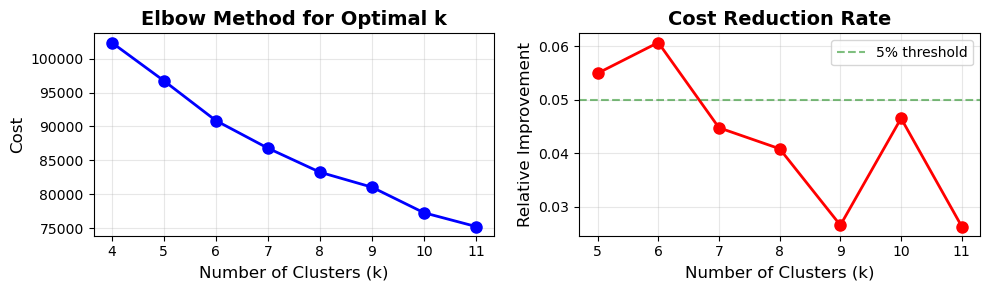


Elbow Analysis Results:
             cost  rel_improve
4   102379.280865          NaN
5    96751.524765     0.054970
6    90875.675185     0.060731
7    86806.045219     0.044782
8    83260.356402     0.040846
9    81050.768702     0.026538
10   77278.092694     0.046547
11   75246.304436     0.026292

Sorted by Relative Improvement:
             cost  rel_improve
6    90875.675185     0.060731
5    96751.524765     0.054970
10   77278.092694     0.046547
7    86806.045219     0.044782
8    83260.356402     0.040846
9    81050.768702     0.026538
11   75246.304436     0.026292
4   102379.280865          NaN


In [208]:
print("\n" + "="*70)
print("ELBOW METHOD - Finding Optimal K")
print("="*70)

# Run elbow analysis
K_range = list(range(4, 12))
elbow_df = elbow_analysis(X, categorical_indices, K_range)

print("\nElbow Analysis Results:")
print(elbow_df)
print("\nSorted by Relative Improvement:")
print(elbow_df.sort_values("rel_improve", ascending=False))

# K-Prototypes - STEP 3 - GAMMA TUNING

In [209]:
def gamma_tuning(X, categorical_indices, gammas, k=7, n_init=3, random_state=42):
    """
    Test different gamma values to balance categorical vs numerical importance.
    Higher gamma = more weight on categorical features.
    """
    print(f"Testing {len(gammas)} gamma values for k={k}...")

    results = []
    for g in gammas:
        print(f"  γ={g:.2f}...", end=" ")
        model = KPrototypes(
            n_clusters=k,
            init="Cao",
            n_init=n_init,
            max_iter=50,
            verbose=0,
            random_state=random_state,
            gamma=g
        )
        labels = model.fit_predict(X, categorical=categorical_indices)
        cost = model.cost_
        results.append({"gamma": g, "cost": cost})
        print(f"Cost: {cost:.2f}")

    results_df = pd.DataFrame(results).sort_values("cost")

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(results_df['gamma'], results_df['cost'],
             'go-', linewidth=2, markersize=8)
    plt.xlabel('Gamma (γ)', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.title('Gamma Tuning: Cost vs γ', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

    return results_df

In [ ]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

chosen_k = 6

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2.5, 5)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

# K-Prototypes - STEP 4 - FINAL CLUSTERING WITH EVALUATION METRICS

In [211]:
def fit_and_evaluate(X, categorical_indices, k, gamma, enc, random_state=42):
    """
    Fit K-Prototypes and calculate multiple quality metrics.
    """
    print(f"\nFitting K-Prototypes: k={k}, γ={gamma}")
    print("This may take several minutes...")

    kproto = KPrototypes(
        n_clusters=k,
        init="Cao",
        gamma=gamma,
        n_init=5,
        max_iter=100,
        random_state=random_state,
        verbose=1
    )
    labels = kproto.fit_predict(X, categorical=categorical_indices)

    # Calculate metrics
    metrics = {}
    metrics['cost'] = kproto.cost_
    metrics['n_iter'] = kproto.n_iter_

    # Sample for silhouette (too slow on full dataset)
    sample_size = min(5000, X.shape[0])
    rng = np.random.RandomState(random_state)
    idx = rng.choice(X.shape[0], size=sample_size, replace=False)

    print("\nCalculating quality metrics (using sample)...")

    # Gower distance approximation for mixed data
    # Use only numerical features for standard metrics
    n_cat = len(categorical_indices)
    X_num = X[:, n_cat:]

    try:
        metrics['silhouette'] = silhouette_score(X_num[idx], labels[idx])
        metrics['calinski_harabasz'] = calinski_harabasz_score(X_num, labels)
        metrics['davies_bouldin'] = davies_bouldin_score(X_num, labels)
    except Exception as e:
        print(f"Warning: Could not calculate some metrics: {e}")
        metrics['silhouette'] = np.nan
        metrics['calinski_harabasz'] = np.nan
        metrics['davies_bouldin'] = np.nan

    # Cluster size balance
    sizes = pd.Series(labels).value_counts().sort_index()
    metrics['size_ratio'] = sizes.max() / sizes.min()
    metrics['min_cluster_size'] = sizes.min()
    metrics['max_cluster_size'] = sizes.max()

    print("\n" + "="*50)
    print("CLUSTERING QUALITY METRICS")
    print("="*50)
    print(f"Cost:                    {metrics['cost']:.2f}")
    print(f"Iterations:              {metrics['n_iter']}")
    print(
        f"Silhouette Score:        {metrics['silhouette']:.4f} (higher is better: -1 to 1)")
    print(
        f"Calinski-Harabasz:       {metrics['calinski_harabasz']:.2f} (higher is better)")
    print(
        f"Davies-Bouldin:          {metrics['davies_bouldin']:.4f} (lower is better)")
    print(f"Size Ratio (max/min):    {metrics['size_ratio']:.2f}")
    print(f"Cluster Sizes:           {sizes.min()} to {sizes.max()}")
    print("="*50)

    return kproto, labels, metrics, sizes

In [212]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen k and gamma
chosen_k = 6  # Update based on elbow analysis
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=6, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 5665, ncost: 150036.67780859215
Run: 1, iteration: 2/100, moves: 1551, ncost: 148272.69674859746
Run: 1, iteration: 3/100, moves: 917, ncost: 148107.855324288
Run: 1, iteration: 4/100, moves: 299, ncost: 148066.93878675083
Run: 1, iteration: 5/100, moves: 156, ncost: 148055.7739792804
Run: 1, iteration: 6/100, moves: 75, ncost: 148053.35109249855
Run: 1, iteration: 7/100, moves: 23, ncost: 148052.9349790431
Run: 1, iteration: 8/100, moves: 32, ncost: 148052.0008190178
Run: 1, iteration: 9/100, moves: 31, ncost: 148051.26468661297
Run: 1, iteration: 10/100, moves: 17, ncost: 148050.99409872337
Run: 1, iteration: 11/100, moves: 12, ncost: 148050.8283361887
Run: 1, iteration: 12/100, moves: 13, ncos

Fitting K-Prototypes: k=6, γ=1.5  
CLUSTERING QUALITY METRICS

Cost:                    147886.15  
Iterations:              24  
Silhouette Score:        0.1895 (higher is better: -1 to 1)  
Calinski-Harabasz:       2634.32 (higher is better)  
Davies-Bouldin:          1.5242 (lower is better)  
Size Ratio (max/min):    5.83  
Cluster Sizes:           635 to 3702  


# K-Prototypes - STEP 5 - CLUSTER INTERPRETATION

In [213]:
def decode_centroids(kproto, enc, scaler, categorical_cols, numerical_cols, rev_maps):
    """
    Decode K-Prototypes centroids to interpretable format.

    Parameters:
    - kproto: Fitted KPrototypes model
    - enc: OrdinalEncoder used for categorical features
    - scaler: StandardScaler used for numerical features
    - categorical_cols: List of categorical column names
    - numerical_cols: List of numerical column names
    - rev_maps: Reverse mapping dictionary for categorical features
    """
    cc = kproto.cluster_centroids_
    n_cat = len(categorical_cols)
    n_num = len(numerical_cols)

    # KPrototypes stores centroids as [NUMERICAL, CATEGORICAL] regardless of input order!
    num_centroids = np.asarray(cc)[:, :n_num].astype(
        float)      # First n_num columns
    cat_centroids = np.asarray(cc)[:, n_num:]      # Last n_cat columns

    # Inverse transform numerical centroids back to original scale
    num_centroids_original = scaler.inverse_transform(num_centroids)

    # Numerical centroids (rounded to 2 decimal places)
    num_centroids_df = pd.DataFrame(
        np.round(num_centroids_original, 2),
        columns=numerical_cols
    )

    # Decode categorical centroids - UPDATED VERSION
    def decode_cat(col, v):
        if pd.isna(v):
            return "(missing)"
        try:
            vi = int(round(float(v)))
        except:
            return "(missing)"

        decoded = rev_maps[col].get(vi, "(missing)")

        # Convert None to a string
        if decoded is None:
            return "(missing)"

        # Convert everything to string for consistency
        return str(decoded)

    cat_centroids_df = pd.DataFrame({
        col: [decode_cat(col, v) for v in cat_centroids[:, j]]
        for j, col in enumerate(categorical_cols)
    })

    centroids_df = pd.concat([cat_centroids_df, num_centroids_df], axis=1)
    centroids_df.index.name = "cluster_id"

    return centroids_df

In [214]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering, rev_maps)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                                0              1              2  \
multiple_pedestrians                      0              0              0   
driver_injury                             0              0              0   
driver_gender                             M              M              M   
natural_light                     light_day      light_day      light_day   
DAY                                       2              4              1   
road_features                 Straight road  Straight road  Straight road   
road_markings_traffic_lights              0              0              0   
TipoStradaDifficulty                      2              2              2   
traffic_density                           1              1              1   
vehicle_type                            Car            Car            Car   
passengers                                0              0              0   
road_conditions_bin             

# K-Prototypes - STEP 6 - CLUSTER PROFILES

In [215]:
def create_cluster_summary(df_enc, categorical_cols, numerical_cols):
    """
    Create comprehensive cluster summary statistics.
    """
    # Numerical means
    num_summary = df_enc.groupby("cluster_id")[numerical_cols].mean()

    # Categorical modes
    mode_summary = df_enc.groupby("cluster_id")[categorical_cols].agg(
        lambda s: s.value_counts(dropna=False).idxmax()
    )

    # Top 3 proportions for each categorical
    def top3_props(s):
        vc = s.value_counts(dropna=False, normalize=True)
        return " | ".join([f"{k}: {p:.1%}" for k, p in vc.head(3).items()])

    top3_summary = df_enc.groupby("cluster_id")[
        categorical_cols].agg(top3_props)

    # Combine
    summary = num_summary.join(mode_summary, rsuffix='_mode')

    return summary, top3_summary

In [216]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nCluster Summary (Numerical Means + Categorical Modes):")
print(summary.T)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Cluster Summary (Numerical Means + Categorical Modes):
cluster_id                                0              1              2  \
time_sin                           0.022118       0.502083      -0.563333   
time_cos                          -0.886308      -0.705844      -0.166318   
temperature_2m (°C)               24.644172      11.906348      13.493701   
relative_humidity_2m (%)          49.051679      79.327391      87.461417   
precipitation (mm)                  0.00943       0.056861       2.114803   
wind_gusts_10m (km/h)             22.415051      18.531551      35.273228   
weather_days_since_last_rain       3.037407       1.798656        0.07664   
male_proportion                    0.408645        0.46162       0.476115   
multiple_pedestrians                      0              0              0   
driver_injury                             0              0              0   
driver_gender                             M              M              M   
natural_light       

# K-Prototypes - STEP 7 - DISTINCTIVE FEATURES (LIFT ANALYSIS)

In [217]:
def top_lifts_for_cluster(df_enc, cluster_id, cat_cols, topn=8, min_prop=0.07):
    """
    Identify distinctive categorical features for each cluster using lift.
    Lift = (proportion in cluster) / (proportion overall)
    """
    dfc = df_enc[df_enc["cluster_id"] == cluster_id]
    out = []

    for col in cat_cols:
        glob = df_enc[col].value_counts(normalize=True, dropna=False)
        clus = dfc[col].value_counts(normalize=True, dropna=False)

        for val, p_c in clus.items():
            p_g = glob.get(val, 0.0)
            if p_c >= min_prop and p_g > 0:
                lift = p_c / p_g
                out.append({
                    'feature': col,
                    'value': val,
                    'cluster_prop': round(p_c, 2),
                    'overall_prop': round(p_g, 2),
                    'lift': round(lift, 2)
                })

    lift_df = pd.DataFrame(out).sort_values(['lift', 'cluster_prop'],
                                            ascending=[False, False])
    return lift_df.head(topn)

In [218]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
             feature     value  cluster_prop  overall_prop  lift
       natural_light light_day          1.00          0.69  1.44
                 DAY         2          0.24          0.17  1.38
 road_conditions_bin         0          0.94          0.76  1.24
                 DAY         5          0.18          0.16  1.13
       driver_gender         F          0.23          0.21  1.11
TipoStradaDifficulty         1          0.28          0.25  1.10
     traffic_density         1          0.72          0.67  1.07
 severity_winsorized         0          0.14          0.13  1.07

CLUSTER 1 - Most Distinctive Features
                     feature                 value  cluster_prop  overall_prop  lift
               natural_light             light_day          0.92          0.69  1.33
                         DAY                     4          0.21          0.17  1.28
             traffic_density     

# K-Prototypes - STEP 8 - EXPORT RESULTS

In [219]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\kproto_results_13_k6_g1-5.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_assignments_13_k6_g1-5.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\kproto_results_13_k6_g1-5.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!


# REGROUP OF DAYS - TRY AGAIN!

In [220]:
# =============================================================================
# DAY BINARY GROUPING FEATURE ENGINEERING
# =============================================================================
def create_day_binary(df, day_column='DAY'):
    """
    Regroup DAY feature into binary categories:
    - Mon-Fri (1-5) → 'Weekday'
    - Sat-Sun (6-7) → 'Weekend'

    Parameters:
    -----------
    df : pd.DataFrame
        Input dataframe
    day_column : str
        Name of the day column (default: 'DAY')

    Returns:
    --------
    pd.DataFrame
        Dataframe with new 'DAY_BINARY' column
    """
    df = df.copy()

    # Define mapping
    day_binary_mapping = {
        1: 'Weekday',  # Monday
        2: 'Weekday',  # Tuesday
        3: 'Weekday',  # Wednesday
        4: 'Weekday',  # Thursday
        5: 'Weekday',  # Friday
        6: 'Weekend',  # Saturday
        7: 'Weekend'   # Sunday
    }

    # Apply mapping
    if day_column in df.columns:
        df['DAY_BINARY'] = df[day_column].map(day_binary_mapping)
        print(f"\n✓ Created DAY_BINARY feature from {day_column}")
        print(f"  Distribution:")
        print(df['DAY_BINARY'].value_counts().sort_index())
    else:
        raise ValueError(f"Column '{day_column}' not found in dataframe")

    return df

In [221]:
categorical_for_clustering

['multiple_pedestrians',
 'driver_injury',
 'driver_gender',
 'natural_light',
 'DAY',
 'road_features',
 'road_markings_traffic_lights',
 'TipoStradaDifficulty',
 'traffic_density',
 'vehicle_type',
 'passengers',
 'road_conditions_bin',
 'road_signage',
 'severity_winsorized']

In [222]:
df = create_day_binary(df, day_column='DAY')


✓ Created DAY_BINARY feature from DAY
  Distribution:
DAY_BINARY
Weekday    12268
Weekend     2581
Name: count, dtype: int64


In [223]:
categorical_for_clustering.remove("DAY")

In [229]:
categorical_for_clustering.append("DAY_BINARY")

In [231]:
categorical_for_clustering

['multiple_pedestrians',
 'driver_injury',
 'driver_gender',
 'natural_light',
 'road_features',
 'road_markings_traffic_lights',
 'TipoStradaDifficulty',
 'traffic_density',
 'vehicle_type',
 'passengers',
 'road_conditions_bin',
 'road_signage',
 'severity_winsorized',
 'DAY_BINARY']

In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-null  int32                      
 9   DataOraIncidente 

In [233]:
df.to_parquet('013_data_for_clustering.parquet', index=False)

In [234]:
columns_for_analysis = categorical_for_clustering + numerical_for_clustering
df_filtered = df[columns_for_analysis].copy()

In [235]:
print("="*70)
print("K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME")
print("="*70)

# Run preprocessing
X, categorical_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
    df_filtered, categorical_for_clustering, numerical_for_clustering)

K-PROTOTYPES CLUSTERING - PEDESTRIAN ACCIDENTS IN ROME

✓ Preprocessing complete:
  Shape: (14849, 22)
  Categorical features: 14
  Numerical features: 8
  dtype: float32



ELBOW METHOD - Finding Optimal K
Using 14849 samples for elbow analysis...
  Running k=4... Cost: 97584.71
  Running k=5... Cost: 91998.61
  Running k=6... Cost: 86142.72
  Running k=7... Cost: 82077.34
  Running k=8... Cost: 78501.04
  Running k=9... Cost: 76242.00
  Running k=10... Cost: 73349.65
  Running k=11... Cost: 70844.90


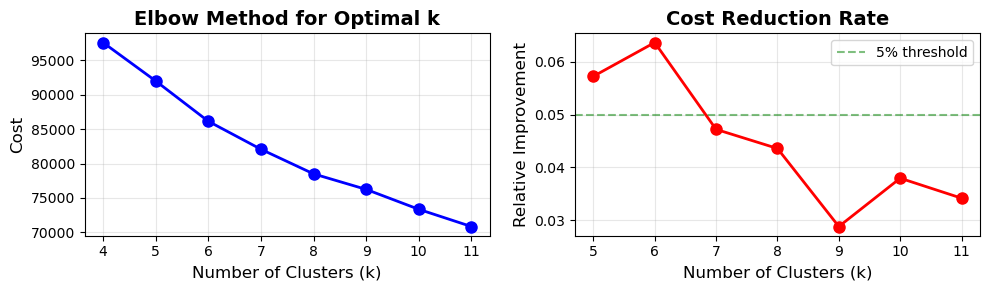


Elbow Analysis Results:
            cost  rel_improve
4   97584.706608          NaN
5   91998.609578     0.057244
6   86142.719360     0.063652
7   82077.343198     0.047193
8   78501.042856     0.043572
9   76242.000931     0.028777
10  73349.652337     0.037936
11  70844.897642     0.034148

Sorted by Relative Improvement:
            cost  rel_improve
6   86142.719360     0.063652
5   91998.609578     0.057244
7   82077.343198     0.047193
8   78501.042856     0.043572
10  73349.652337     0.037936
11  70844.897642     0.034148
9   76242.000931     0.028777
4   97584.706608          NaN


In [236]:
print("\n" + "="*70)
print("ELBOW METHOD - Finding Optimal K")
print("="*70)

# Run elbow analysis
K_range = list(range(4, 12))
elbow_df = elbow_analysis(X, categorical_indices, K_range)

print("\nElbow Analysis Results:")
print(elbow_df)
print("\nSorted by Relative Improvement:")
print(elbow_df.sort_values("rel_improve", ascending=False))

## TRY K = 6 


GAMMA TUNING
Testing 3 gamma values for k=6...
  γ=0.50... Cost: 86004.07
  γ=1.25... Cost: 121786.34
  γ=2.00... Cost: 159191.47


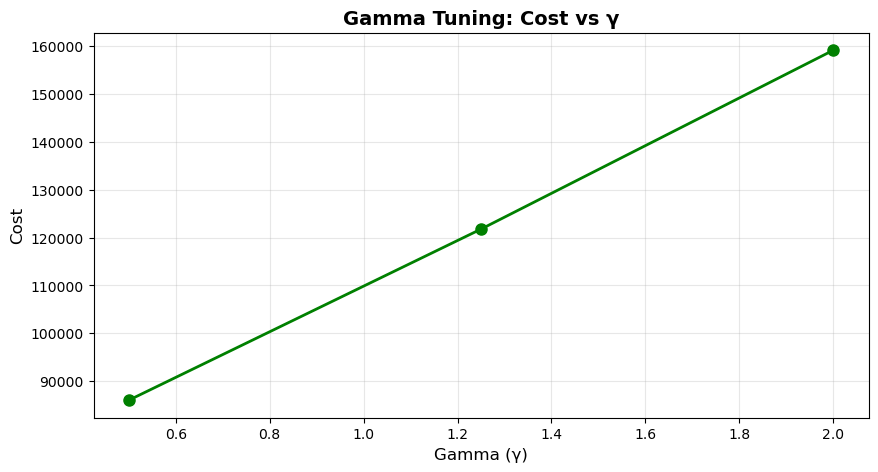


Gamma Tuning Results:
   gamma           cost
0   0.50   86004.073724
1   1.25  121786.343666
2   2.00  159191.467432


In [237]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

chosen_k = 6

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2, 3)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

In [101]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen gamma
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=6, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 5392, ncost: 147783.84843259602
Run: 1, iteration: 2/100, moves: 1372, ncost: 147002.0183280224
Run: 1, iteration: 3/100, moves: 1236, ncost: 145443.83741109748
Run: 1, iteration: 4/100, moves: 1114, ncost: 144598.6929754743
Run: 1, iteration: 5/100, moves: 614, ncost: 144536.58334639992
Run: 1, iteration: 6/100, moves: 128, ncost: 144525.6719055304
Run: 1, iteration: 7/100, moves: 84, ncost: 144521.3907313313
Run: 1, iteration: 8/100, moves: 41, ncost: 144520.15955411005
Run: 1, iteration: 9/100, moves: 32, ncost: 144519.40156663608
Run: 1, iteration: 10/100, moves: 33, ncost: 144518.71037702812
Run: 1, iteration: 11/100, moves: 27, ncost: 144518.36172840363
Run: 1, iteration: 12/100, moves: 5, 

Converged: 15 iterations → the algorithm settled.

Silhouette = 0.1864 → weak separation - some structure, but clusters overlap.
(rule-of-thumb: <0.10 poor, 0.10–0.25 weak, 0.25–0.5 reasonable, >0.5 strong).  

Calinski–Harabasz = 2590 → only meaningful relative to other K; higher vs neighbouring K is better. On its own it just says “some between-cluster spread”.

Davies–Bouldin = 1.526 → moderate  
(closer to 0 is better; <1.2 would be nice, >2 is often messy).

Size ratio = 6.22 (min 640, max 3980) → imbalanced.  
Likely one “catch-all” cluster plus smaller, tighter ones.

Verdict

Usable but not great. There’s a signal, but clusters still overlap and one is quite large.

In [ ]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering, rev_maps)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                                   0                 1  \
time_sin                                   0.4               0.4   
time_cos                                   0.3               0.3   
temperature_2m (°C)                      24.24             24.24   
relative_humidity_2m (%)                 68.84             68.84   
precipitation (mm)                        0.14              0.14   
wind_gusts_10m (km/h)                     33.8              33.8   
weather_days_since_last_rain              6.54              6.54   
male_proportion                           1.95              1.46   
multiple_pedestrians                       1.0               0.0   
driver_injury                              NaN               0.0   
driver_gender                             None                 F   
natural_light                      light_night         light_day   
road_features                            Curve             Curve   
road

In [105]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nCluster Summary (Numerical Means + Categorical Modes):")
print(summary.T)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Cluster Summary (Numerical Means + Categorical Modes):
cluster_id                                0              1              2  \
time_sin                           0.491656      -0.344859      -0.810811   
time_cos                          -0.712243      -0.333193      -0.283153   
temperature_2m (°C)               12.262338      16.103121       20.03245   
relative_humidity_2m (%)           78.49974      68.070828      56.738281   
precipitation (mm)                 0.054442       0.002761       0.041741   
wind_gusts_10m (km/h)             18.576208      17.430852       31.93764   
weather_days_since_last_rain       1.799048      14.110344       1.933815   
male_proportion                    0.462727       0.455782       0.491118   
multiple_pedestrians                      0              0              0   
driver_injury                             0              0              0   
driver_gender                             M              M              M   
natural_light       

In [106]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
                     feature                 value  cluster_prop  overall_prop  lift
               natural_light             light_day          0.92          0.69  1.33
             traffic_density                     2          0.12          0.09  1.27
                    DAY_PAIR               Tue-Wed          0.40          0.34  1.17
road_markings_traffic_lights                     1          0.09          0.08  1.08
                vehicle_type Motorcycle_or_scooter          0.23          0.21  1.07
               driver_gender                     F          0.22          0.21  1.06
        TipoStradaDifficulty                     2          0.50          0.48  1.04
               road_features          Intersection          0.28          0.27  1.04

CLUSTER 1 - Most Distinctive Features
             feature                 value  cluster_prop  overall_prop  lift
 road_conditions_bin           

In [107]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\kproto_results_13_k6_g1-5.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_assignments_13_k6_g1-5.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\kproto_results_13_k6_g1-5.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!


## TRY K = 5


GAMMA TUNING
Testing 5 gamma values for k=5...
  γ=0.50... Cost: 95533.53
  γ=1.00... Cost: 122821.56
  γ=1.50... Cost: 149991.99
  γ=2.00... Cost: 176807.69
  γ=2.50... Cost: 203335.18


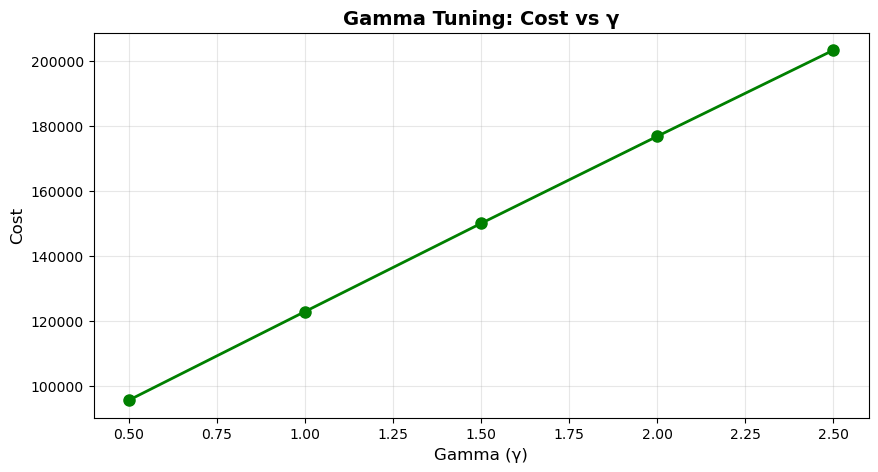


Gamma Tuning Results:
   gamma           cost
0    0.5   95533.525831
1    1.0  122821.563325
2    1.5  149991.989595
3    2.0  176807.688783
4    2.5  203335.183359


In [108]:
print("\n" + "="*70)
print("GAMMA TUNING")
print("="*70)

chosen_k = 5

# Run gamma tuning (adjust k based on elbow results)
gammas = np.linspace(0.5, 2.5, 5)
gamma_results = gamma_tuning(X, categorical_indices, gammas, k=chosen_k)
print("\nGamma Tuning Results:")
print(gamma_results)

In [109]:
print("\n" + "="*70)
print("FINAL CLUSTERING & QUALITY ASSESSMENT")
print("="*70)

# Set your chosen gamma
chosen_gamma = 1.5  # Update based on gamma tuning

kproto, labels, metrics, cluster_sizes = fit_and_evaluate(
    X, categorical_indices, chosen_k, chosen_gamma, enc
)

# Add labels to dataframe
df_enc = df.copy()
df_enc["cluster_id"] = labels

print("\nCluster Sizes:")
print(cluster_sizes)


FINAL CLUSTERING & QUALITY ASSESSMENT

Fitting K-Prototypes: k=5, γ=1.5
This may take several minutes...
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 7141, ncost: 153201.144986183
Run: 1, iteration: 2/100, moves: 2240, ncost: 151473.25129489895
Run: 1, iteration: 3/100, moves: 1270, ncost: 150483.3702610704
Run: 1, iteration: 4/100, moves: 599, ncost: 150388.4486431345
Run: 1, iteration: 5/100, moves: 211, ncost: 150361.4249376607
Run: 1, iteration: 6/100, moves: 137, ncost: 150348.09217405607
Run: 1, iteration: 7/100, moves: 104, ncost: 150341.5260853082
Run: 1, iteration: 8/100, moves: 66, ncost: 150337.58619338315
Run: 1, iteration: 9/100, moves: 50, ncost: 150336.13148493404
Run: 1, iteration: 10/100, moves: 33, ncost: 150335.33802437273
Run: 1, iteration: 11/100, moves: 18, ncost: 150335.09757014757
Run: 1, iteration: 12/100, moves: 10, n

Silhouette = 0.179 → weak separation (lower than your ~0.186 runs).

DB = 1.67 → worse (higher) than before.

Cost = 149,992 → worse (higher).

CH = 2668 → slightly higher, but CH alone isn’t enough to offset the other drops.

Size ratio = 6.39 (646 ↔ 4,131) → still very imbalanced; likely a catch-all cluster.

51 iterations → harder convergence (often a poor init/seed or noisy features).

In [110]:
print("\n" + "="*70)
print("CLUSTER INTERPRETATION")
print("="*70)

centroids_pretty = decode_centroids(
    kproto, enc, scaler, categorical_for_clustering, numerical_for_clustering)
print("\nCluster Centroids:")
print(centroids_pretty.T)


CLUSTER INTERPRETATION

Cluster Centroids:
cluster_id                                   0                 1  \
time_sin                                   0.4               0.4   
time_cos                                   0.3               0.3   
temperature_2m (°C)                      24.24             24.24   
relative_humidity_2m (%)                 68.84             68.84   
precipitation (mm)                        0.14              0.14   
wind_gusts_10m (km/h)                     33.8              33.8   
weather_days_since_last_rain              6.54              6.54   
male_proportion                           1.95              1.46   
multiple_pedestrians                       0.0               1.0   
driver_injury                              NaN               NaN   
driver_gender                                M              None   
natural_light                             None       light_night   
road_features                            Curve             Curve   
road

In [111]:
summary, top3_summary = create_cluster_summary(
    df_enc, categorical_for_clustering, numerical_for_clustering)

print("\nCluster Summary (Numerical Means + Categorical Modes):")
print(summary.T)

print("\nTop 3 Categories per Cluster:")
print(top3_summary.T)


Cluster Summary (Numerical Means + Categorical Modes):
cluster_id                                0              1              2  \
time_sin                          -0.188432       0.501054      -0.703737   
time_cos                          -0.744052      -0.716817       0.452914   
temperature_2m (°C)               25.379618        12.4664      13.634837   
relative_humidity_2m (%)          47.139297      78.064149      80.993984   
precipitation (mm)                 0.005053       0.047858       0.071343   
wind_gusts_10m (km/h)             23.474872      18.014887      15.016544   
weather_days_since_last_rain        5.13032       2.359104        2.59459   
male_proportion                    0.419762       0.447854       0.556586   
multiple_pedestrians                      0              0              0   
driver_injury                             0              0              0   
driver_gender                             M              M              M   
natural_light       

In [112]:
print("\n" + "="*70)
print("DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)")
print("="*70)

distinctive = {
    k: top_lifts_for_cluster(df_enc, k, categorical_for_clustering)
    for k in sorted(df_enc["cluster_id"].unique())
}

for cluster_id, lift_df in distinctive.items():
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id} - Most Distinctive Features")
    print(f"{'='*50}")
    print(lift_df.to_string(index=False))


DISTINCTIVE FEATURES BY CLUSTER (Lift Analysis)

CLUSTER 0 - Most Distinctive Features
             feature     value  cluster_prop  overall_prop  lift
       natural_light light_day          0.99          0.69  1.43
            DAY_PAIR   Tue-Wed          0.45          0.34  1.32
 road_conditions_bin         0          0.96          0.76  1.26
       driver_gender         F          0.24          0.21  1.13
TipoStradaDifficulty         1          0.28          0.25  1.10
 severity_winsorized         0          0.14          0.13  1.09
     traffic_density         1          0.71          0.67  1.06
        vehicle_type       Car          0.70          0.66  1.05

CLUSTER 1 - Most Distinctive Features
                     feature                 value  cluster_prop  overall_prop  lift
               natural_light             light_day          0.92          0.69  1.34
             traffic_density                     2          0.12          0.09  1.24
                    DAY_PAIR     

In [113]:
print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Save summary
output_path = r"C:\Users\lucyq\Dropbox\AMDP\THESIS\kproto_results_13_k5_g1-5.xlsx"
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    summary.to_excel(writer, sheet_name='Summary')
    top3_summary.to_excel(writer, sheet_name='Top3_Proportions')
    centroids_pretty.to_excel(writer, sheet_name='Centroids')
    pd.DataFrame([metrics]).to_excel(writer, sheet_name='Metrics', index=False)
    cluster_sizes.to_frame('size').to_excel(writer, sheet_name='Cluster_Sizes')

print(f"✓ Results saved to: {output_path}")

# Save cluster assignments
df_enc[['cluster_id']].to_csv(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\cluster_assignments_13_k5_g1-5.csv"
)
print("✓ Cluster assignments saved")

print("\n" + "="*70)
print("CLUSTERING COMPLETE!")
print("="*70)


EXPORTING RESULTS
✓ Results saved to: C:\Users\lucyq\Dropbox\AMDP\THESIS\kproto_results_13_k5_g1-5.xlsx
✓ Cluster assignments saved

CLUSTERING COMPLETE!


k = 5, gamma = 1.5, K-Prototypes

Pairing the days seems to have helped the clustering although another feature which may be having the same problem is the time of day. 

Other features consistently equal across clusters:
- multiple_pedestrians  consistently 0    single pedestrian accident
- driver_injury consistently 0     driver unhurt
- road_features     straight road
- road_markings_traffic_lights  consistently 0  (no traffic light)
- passengers    consistently 0   driver alone in vehicle
- road_signage  on road and signposted signals (possibly zebra crossing/intersection)

In [ ]:
metadata = {
    'notebook': '013 Clustering k-prototypes.ipynb',
    'step': 'k-prototypes clustering: search, selection, evaluation, profiling',

    # Lineage
    'input_file': '012_data_cluster_ready.parquet',
    'output_file': '013_data_for_clustering.parquet',


    # Feature sets actually used for the model
    'features_used': {
        'numeric': '<fill: list of numeric feature names>',
        'categorical': '<fill: list of categorical feature names>',
        'id_columns': ['Protocollo'],
        'kept_for_ref': ['Latitude', 'Longitude', 'timestamp_local']
    },

    # Preprocessing
    'scaler': {
        'name': 'RobustScaler',
        'params': {'with_centering': True, 'with_scaling': True},
        'fitted_on': 'numeric features only'
    },
    'categorical_dtype_ok': True,     # pandas CategoricalDtype set for all categoricals
    'rare_category_collapse': {
        'applied': '<fill True/False>',
        'threshold': {'min_prop': 0.01, 'min_count': 100},
        'columns': '<fill: list or []>'
    },

    # Algorithm & search space
    'algorithm': {'lib': 'kmodes.KPrototypes', 'version': '<fill>'},
    'init_method': 'Huang',   # or 'Cao'
    'search_space': {
        'K_grid': [2, 3, 4, 5, 6, 7, 8, 9, 10],
        'gamma_grid': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
        'n_init': 10,
        'max_iter': 100,
        'random_seeds': [0, 1, 7, 42, 2025]
    },
    'early_stopping': False,

    # Model selection outcome
    'selection_metric': 'objective_cost',   # lower is better
    'best_model': {
        'K': '<fill>',
        'gamma': '<fill>',
        'cost': '<fill>',
        'iterations_run': '<fill>',
        'seed': '<fill>'
    },
    'search_results_file': '013_kproto_search_results.csv',

    # Labels & exports
    'labels_column': 'cluster_id',
    'cluster_sizes': '<fill: dict like {0: n0, 1: n1, ...}>',
    'exports': {
        'model_pickle': '013_kproto_model.pkl',
        'labels_parquet': '013_cluster_labels.parquet',
        'labels_csv': '013_cluster_labels.csv',
        'profiles_csv': '013_cluster_profiles.csv',
        'plots': ['013_elbow_cost_by_K.png', '013_gamma_cost_heatmap.png']
    },

    # Evaluation (use what you computed; leave N/A if not)
    'evaluation': {
        'cost_by_K': '<fill: dict or path to csv/plot>',
        # silhouette on Gower distance (proxy)
        'silhouette_gower': '<fill or N/A>',
        'davies_bouldin_gower': '<fill or N/A>',
        'within_between_ratio': '<fill or N/A>',
        'stability_across_seeds': {
            'measured': '<fill True/False>',
            'variation_index_mean': '<fill or N/A>',   # e.g., VI / NMI / ARI across seeds
            'notes': 'lower variation indicates more stable clustering'
        }
    },

    # Profiling (per-cluster summaries)
    'profiling': {
        'numeric_stats': ['mean', 'median', 'p25', 'p75'],
        'categorical_topN': 5,
        'top_lifts': {
            'function': 'top_lifts_for_cluster',
            'lift': 'p(cluster)/p(global)',
            'min_prop': 0.07,
            'topn': 8
        },
        'profile_columns': '<fill: key columns used for narrative>'
    },

    # QA checks
    'qa_checks': {
        'no_na_in_features': True,
        'numeric_finite_all': True,
        'categorical_levels_ok': True,
        'scaled_variance_reasonable': True,
        'labels_length_matches_rows': True,
        'cost_monotone_vs_init': True  # best-of-n_init decreases vs single init
    },

    # Decisions & rationale
    'decisions_made': [
        'Used RobustScaler on numeric block; left categoricals as CategoricalDtype (no one-hot).',
        'Searched (K, gamma) grid and selected model by lowest objective cost with seed sweep for stability.',
        'Kept a single representation for group size (binary multiple_pedestrians OR binned ped_count_binned).',
        'Excluded highly correlated severity/count features upstream to avoid overweighting numeric distance.',
        'Reported per-cluster lift profiles to support interpretation and downstream mapping.'
    ],

    # Modeling notes
    'modeling_notes': (
        "Re-evaluate gamma if numeric feature set changes. Prefer ordered categoricals as categories; "
        "use ordinal codes only in ablation. Validate clusters on geography and time (e.g., hotspot overlay)."
    ),

    }
}